<h1>
    Compare prediction error with declared error in different goodness
</h1>

In [1]:
import os
import sys

import numpy as np

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)


In [8]:
from src.models.data_selection.data_selector import Data_selector
from src.models.utils import *
import matplotlib.pyplot as plt

In [4]:
csv_read_path = os.path.join(project_root, "data", "processed", "with_prediction.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')
df.dropna(subset=["generation", "prediction", "declared"], inplace=True)


In [13]:
declared_errors, pred_errors, data_sizes = [], [], []
all_goodness = np.arange(7)
for goodness in all_goodness:
    df_selected = Data_selector(df).select_peaks(goodness=goodness)
    generation = df_selected["generation"]
    prediction = df_selected["prediction"]
    declared = df_selected["declared"]
    
    pred_error = compute_relative_rmse(generation, prediction)
    declared_error = compute_relative_rmse(generation, declared)
    
    pred_errors.append(pred_error)
    declared_errors.append(declared_error)
    data_sizes.append(len(generation))

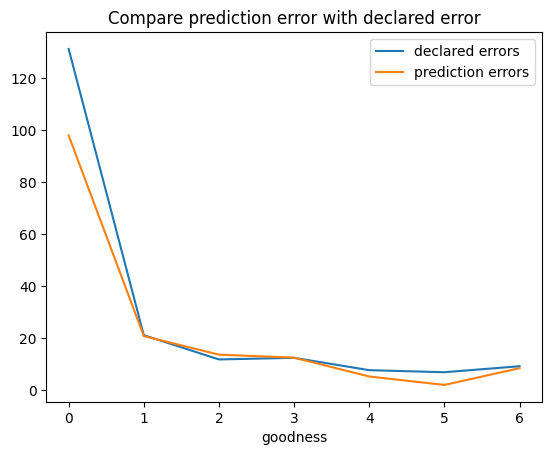

In [16]:
plt.plot(all_goodness, declared_errors, label="declared errors")
plt.plot(all_goodness, pred_errors, label="prediction errors")
plt.title("Compare prediction error with declared error")
plt.xlabel("goodness")
plt.legend()
plt.show()